# 06f - Decision Tree Explanation
Vizualizace rozhodovacího stromu a vysvetleni klasifikace vybrane instance.

**Bod zadani 2:** Vysvetlete, jak model rozhodovacího stromu dospel ke svemu zaveru.
**Bod zadani 3+4+5:** Klasifikace vybrane instance vsemi modely, shoda, spolehlivost.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

ctx           = joblib.load('../results/xai/xai_context.pkl')
X_train_prep  = ctx['X_train_prep']
X_test_prep   = ctx['X_test_prep']
y_test        = ctx['y_test']
tuned_models  = ctx['tuned_models']
student_index = ctx['student_index']
risky_student = ctx['risky_student']
student_prob  = ctx['student_prob']
winning_name  = ctx['winning_name']

# Nacteni Decision Tree — trenovaneho v 032
dt_model = joblib.load('../models/baseline/decision_tree.pkl')

print(f"Vybrana instance: student index {student_index}, riziko {student_prob:.1%}")
print(f"Skutecna trida: {y_test.iloc[student_index]} (1=Dropout, 0=Dostuduje)")
print(f"Feature names ({len(X_test_prep.columns)}): {list(X_test_prep.columns)}")

Vybrana instance: student index 17, riziko 85.9%
Skutecna trida: 1 (1=Dropout, 0=Dostuduje)
Feature names (19): ['Family_Income', 'Study_Hours_per_Day', 'Stress_Index', 'Age_Gap', 'CGPA', 'GPA_trend', 'Department_Arts', 'Department_Business', 'Department_CS', 'Department_Engineering', 'Department_Science', 'Gender', 'Internet_Access', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Semester']


## Vizualizace rozhodovacího stromu (max_depth=3)
Zobrazujeme prvni 3 urovne stromu — hlubsi uzly jsou prilis detailni pro vizualizaci.

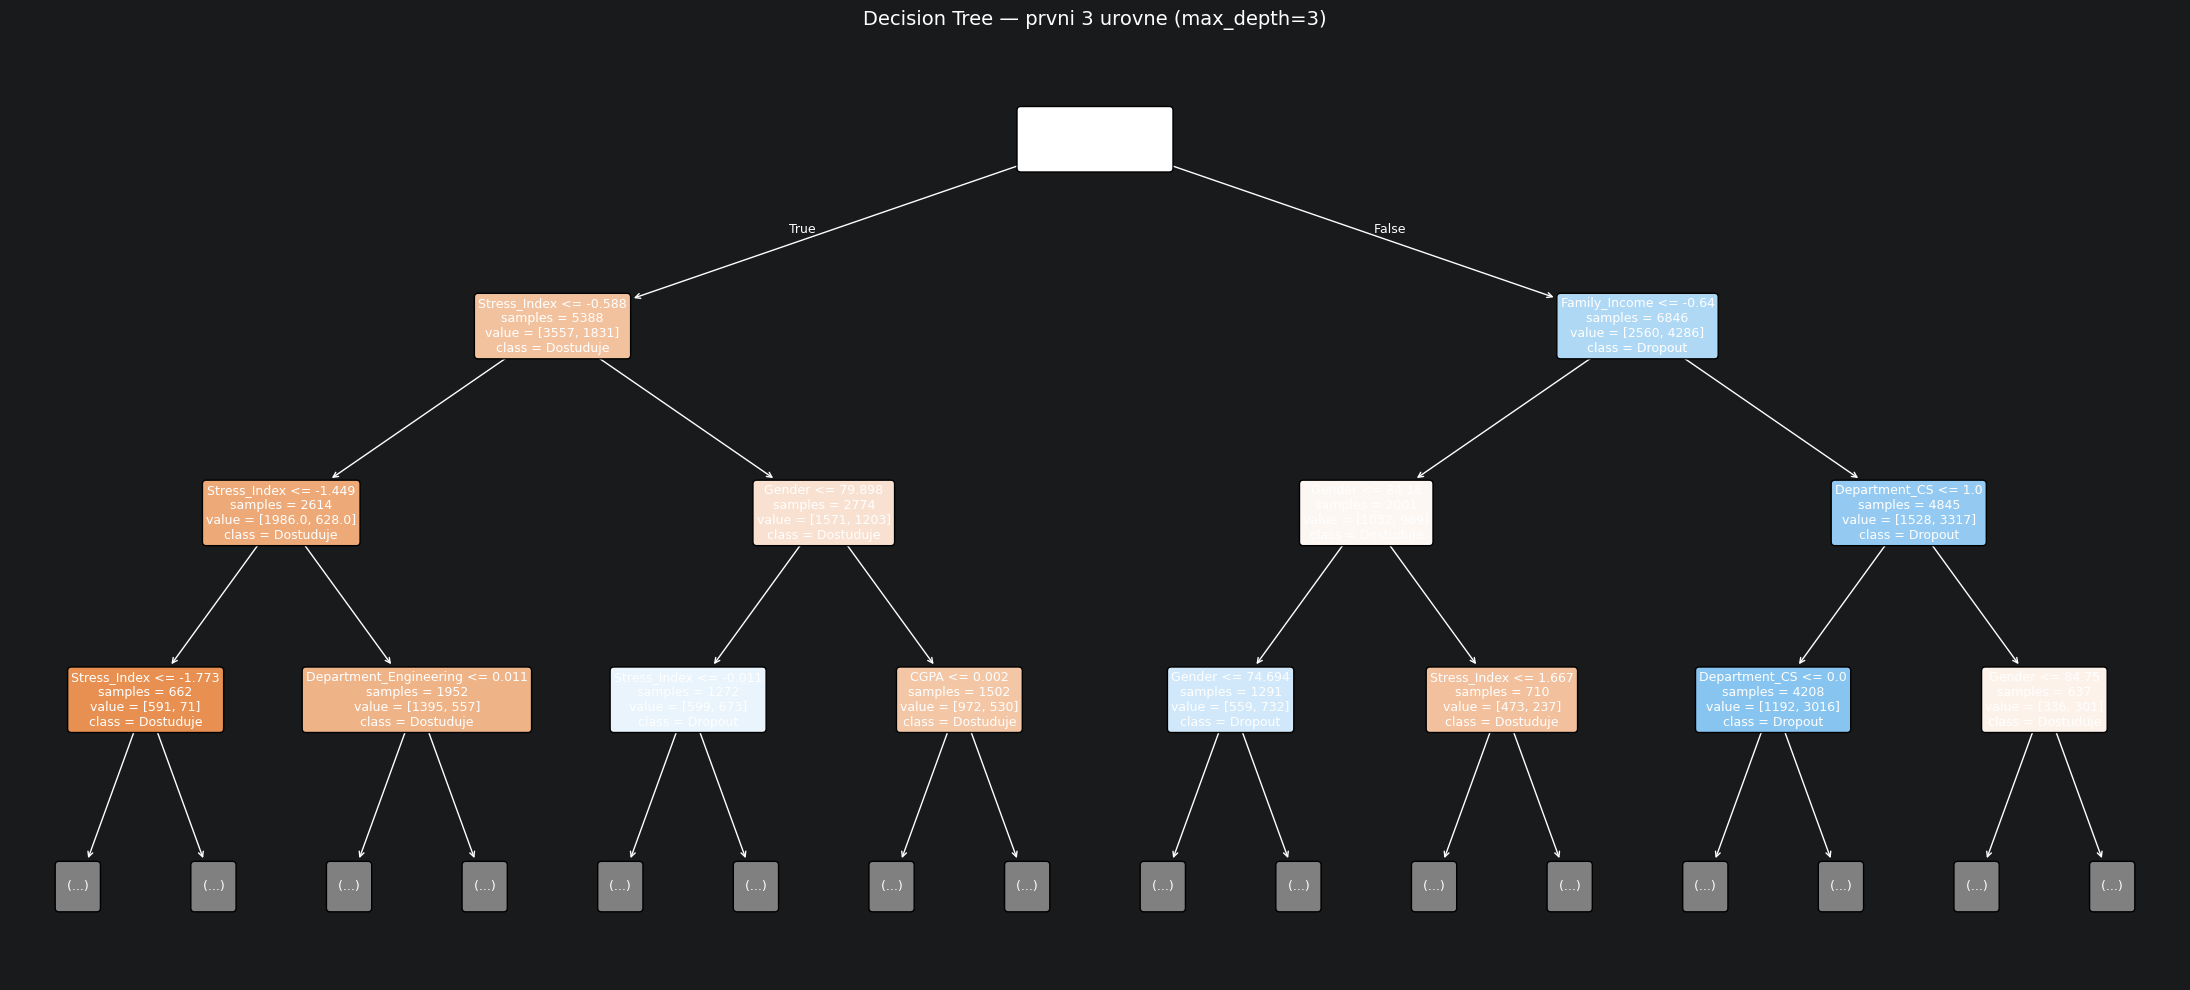

In [18]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=X_test_prep.columns.tolist(),
    class_names=['Dostuduje', 'Dropout'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
    impurity=False,
    proportion=False,
)
ax.set_title('Decision Tree — prvni 3 urovne (max_depth=3)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Cesta rozhodovacím stromem pro vybranou instanci
Sledujeme ktery uzel byl aktivovan pri klasifikaci studenta c. {student_index}.

In [19]:
from sklearn.tree import _tree

def get_decision_path(model, instance, feature_names):
    tree_       = model.tree_
    feature     = tree_.feature
    threshold   = tree_.threshold
    node_ind = model.decision_path(instance.to_frame().T).indices

    path_steps = []
    for i, node in enumerate(node_ind):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            # Listy
            class_idx  = tree_.value[node].argmax()
            class_name = ['Dostuduje', 'Dropout'][class_idx]
            proba      = tree_.value[node][0, class_idx] / tree_.value[node].sum()
            path_steps.append(f"  LEAF → Predikce: {class_name} ({proba:.1%})")
        else:
            feat_name = feature_names[feature[node]]
            val       = float(instance.iloc[feature[node]])
            thr       = threshold[node]
            direction = '<= ' if val <= thr else '> '
            path_steps.append(
                f"  Uzel {node}: {feat_name} = {val:.3f}  {direction}{thr:.3f}"
            )
    return path_steps

feature_names = X_test_prep.columns.tolist()
# 1. Zeptáme se modelu, na jakých 17 sloupcích se učil (tohle on si pamatuje)
expected_features = dt_model.feature_names_in_

# 2. Ořízneme našeho studenta z 19 sloupců jen na těch 17 správných
risky_student_filtered = risky_student[expected_features]

path = get_decision_path(dt_model, risky_student_filtered, expected_features)

print(f"Rozhodovaci cesta pro studenta c. {student_index} (riziko {student_prob:.1%}):")
print(f"{'=' * 60}")
for step in path:
    print(step)

# Tady si z toho uděláme hezkou tabulku s jedním řádkem
student_df = risky_student_filtered.to_frame().T

# A rovnou ji pošleme do modelu (bez reshape)
dt_pred  = dt_model.predict(student_df)[0]
dt_proba = dt_model.predict_proba(student_df)[0]
print(f"\nFinalní predikce DT: {'Dropout' if dt_pred == 1 else 'Dostuduje'}")
print(f"Pravdepodobnost Dropout: {dt_proba[1]:.1%}")

Rozhodovaci cesta pro studenta c. 17 (riziko 85.9%):
  Uzel 0: Stress_Index = 0.278  > -0.011
  Uzel 32: Family_Income = -0.084  > -0.640
  Uzel 48: Department_Science = 1.000  > 1.000
  Uzel 54: Attendance_Rate = 87.600  > 84.750
  Uzel 58: Attendance_Rate = 87.600  <= 87.634
  LEAF → Predikce: Dostuduje (88.2%)

Finalní predikce DT: Dostuduje
Pravdepodobnost Dropout: 11.8%


## Textový výpis celého stromu (pravidla)
Kompaktnı textova reprezentace vsech rozhodovacich pravidel.

In [20]:
rules = export_text(dt_model, feature_names=list(dt_model.feature_names_in_), max_depth=4)
print(rules[:10000])  # prvnich 10000 znaku — cely strom muze byt dlouhy

|--- Stress_Index <= -0.01
|   |--- Stress_Index <= -0.59
|   |   |--- Stress_Index <= -1.45
|   |   |   |--- Stress_Index <= -1.77
|   |   |   |   |--- Study_Hours_per_Day <= 2.63
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Study_Hours_per_Day >  2.63
|   |   |   |   |   |--- class: 1
|   |   |   |--- Stress_Index >  -1.77
|   |   |   |   |--- Age_Gap <= 0.71
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age_Gap >  0.71
|   |   |   |   |   |--- class: 0
|   |   |--- Stress_Index >  -1.45
|   |   |   |--- Gender <= 0.01
|   |   |   |   |--- Department_Engineering <= 0.02
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Department_Engineering >  0.02
|   |   |   |   |   |--- class: 0
|   |   |   |--- Gender >  0.01
|   |   |   |   |--- Gender <= 1.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Gender >  1.00
|   |   |   |   |   |--- class: 0
|   |--- Stress_Index >  -0.59
|   |   |--- Attendance_Rate <= 79.90
|   |   |   |--- Stress_Index <= -0.01
| 

## Bod 3+4+5: Klasifikace vybrané instance všemi modely
Porovname predikci vsech modelu pro studenta c. {student_index}.
- Predikuji vsechny modely stejnou tridu?
- Jaka je spolehlivost (pravdepodobnost) predikce?

Vybrana instance: student c. 17
Skutecna trida:   Dropout (1)
              Model      Predikce P(Dropout) P(Dostuduje) Shoda s vítězem Spravna predikce
Logistic Regression   Dropout (1)      85.9%        14.1%             ANO              ANO
      Random Forest   Dropout (1)      63.0%        37.0%             ANO              ANO
  Gradient Boosting   Dropout (1)      69.2%        30.8%             ANO              ANO
      Decision Tree Dostuduje (0)      11.8%        88.2%              NE               NE


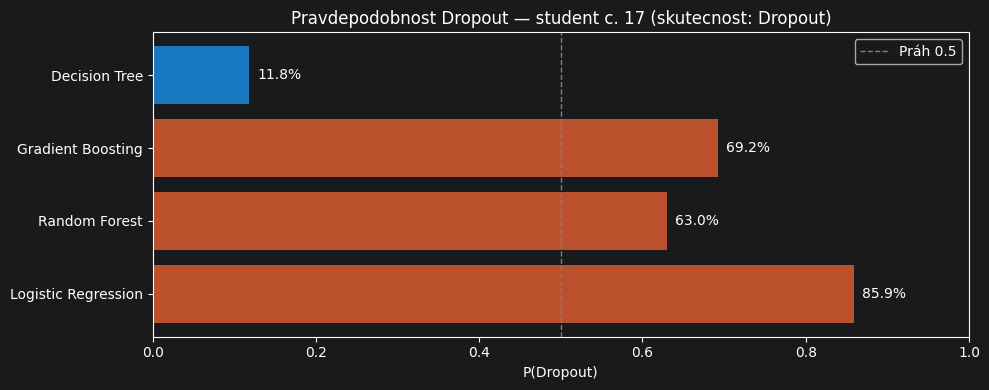


ZAVER: Modely se NESHODUJI — rozlicne predikce pro studenta c. 17
  Logistic Regression: Dropout (1)
  Random Forest: Dropout (1)
  Gradient Boosting: Dropout (1)
  Decision Tree: Dostuduje (0)


In [22]:
all_models = dict(tuned_models)
all_models['Decision Tree'] = dt_model

rows = []
skutecna_trida = int(y_test.iloc[student_index])

for name, model in all_models.items():
    # 1. Zeptáme se aktuálního modelu v cyklu, jaké sloupce přesně vyžaduje
    if hasattr(model, 'feature_names_in_'):
        expected_cols = model.feature_names_in_
        # Ořízneme studenta přesně pro tento model a uděláme z něj tabulku
        X_input = risky_student[expected_cols].to_frame().T
    else:
        # Fallback (pro jistotu)
        X_input = risky_student.to_frame().T

    # 2. Samotná predikce (už používá oříznutá čistá data X_input)
    pred  = int(model.predict(X_input)[0])
    proba = model.predict_proba(X_input)[0]

    rows.append({
        'Model':              name,
        'Predikce':           'Dropout (1)' if pred == 1 else 'Dostuduje (0)',
        'P(Dropout)':         f"{proba[1]:.1%}",
        'P(Dostuduje)':       f"{proba[0]:.1%}",
        'Shoda s vítězem':    'ANO' if pred == 1 else 'NE',
        'Spravna predikce':   'ANO' if pred == skutecna_trida else 'NE',
    })

df_compare = pd.DataFrame(rows)
print(f"Vybrana instance: student c. {student_index}")
print(f"Skutecna trida:   {'Dropout (1)' if skutecna_trida == 1 else 'Dostuduje (0)'}")
print(f"{'=' * 75}")
print(df_compare.to_string(index=False))

# Vizualizace pravdepodobnosti
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#D85A30' if '1' in r['Predikce'] else '#178ADD' for _, r in df_compare.iterrows()]
proba_vals = [float(r['P(Dropout)'].rstrip('%')) / 100 for _, r in df_compare.iterrows()]
bars = ax.barh(df_compare['Model'], proba_vals, color=colors, alpha=0.85)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Práh 0.5')
ax.set_xlabel('P(Dropout)')
ax.set_title(f'Pravdepodobnost Dropout — student c. {student_index} (skutecnost: {"Dropout" if skutecna_trida else "Dostuduje"})', fontsize=12)
ax.set_xlim(0, 1)
for bar, val in zip(bars, proba_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

# Explicitní odpověď: shodují se modely?
predikce_int = [1 if '1' in r['Predikce'] else 0 for r in rows]
if len(set(predikce_int)) == 1:
    print(f"\nZAVER: VSECHNY modely predikuji shodne — {'Dropout (1)' if predikce_int[0] == 1 else 'Dostuduje (0)'}")
else:
    print(f"\nZAVER: Modely se NESHODUJI — rozlicne predikce pro studenta c. {student_index}")
    for r in rows:
        print(f"  {r['Model']}: {r['Predikce']}")